# Gradient Descent - Nonconvex

In this notebook we will explore a more complex model and descent methods to fit it. The model still has only two parameters but has this more complex form:
$$ y = \sin(\theta_0 + 0.06 \, \theta_1 x) \exp\Big( -\frac{\theta_0 + 0.06 \, \theta_1 x)^2}{32.0}\Big)$$

In [17]:
# magic for autoreloading of modules
%reload_ext autoreload
%autoreload 2

# import libraries
import torch
import numpy as np  # for csv loading and plotting
import helpers as hlp
import todos as td

The `data` here is a `torch.tensor` with shape `torch.Size([12, 2])` with inputs $x$ in the first column and output $y$ in the second column.

We will initialize the 2d parameter vector $\theta$, the data, the initial model and the loss contours with the initial parameters.

Initial theta: tensor([[ 0.],
        [12.]])
Initial mse: 0.09543593227863312


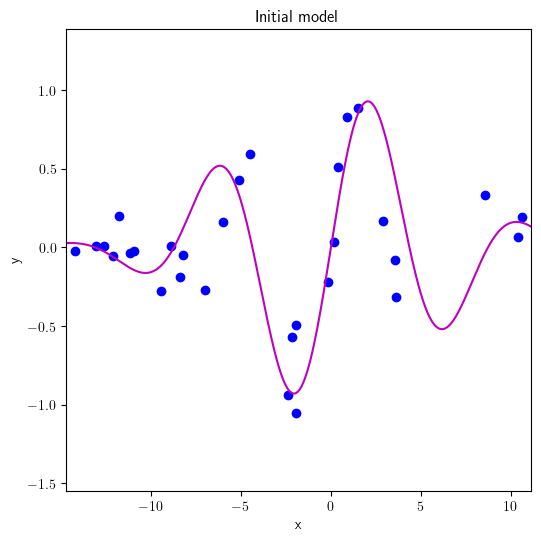

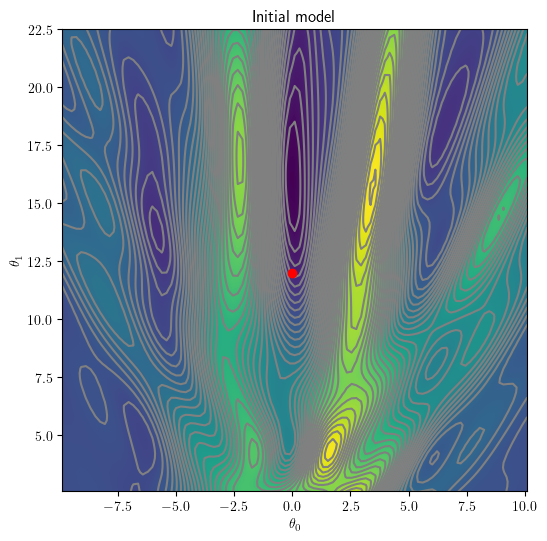

In [18]:
# initialize parameters
theta = torch.randn(2,1)*5.
theta[1,0] = theta[1,0]+10.
theta[0,0] = 0.
theta[1,0] = 12.
print(f'Initial theta: {theta}')

# predict y
x = hlp.gabor_data[:,:1]
y = hlp.gabor_data[:,1:]
y_pred = hlp.gabor_model(x,theta)

# get mse
mse = td.mse(y, y_pred)
print(f'Initial mse: {mse}')

# plot initial model
hlp.plot_model(x, y, theta, model=hlp.gabor_model, title="Initial model")

# plot loss contour
hlp.loss_contour(x,y,model=hlp.gabor_model,loss_func=td.mse,type=1,title="Initial model",theta_list=theta)


Let's hope your gradient descent function still works!

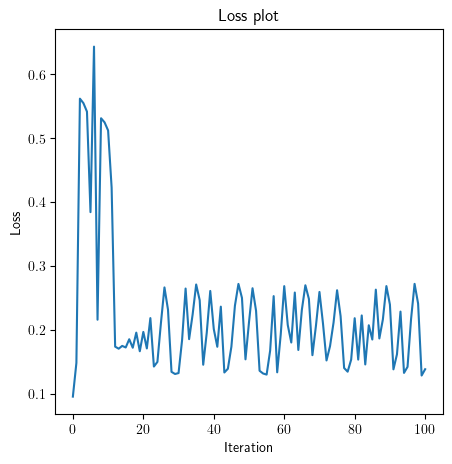

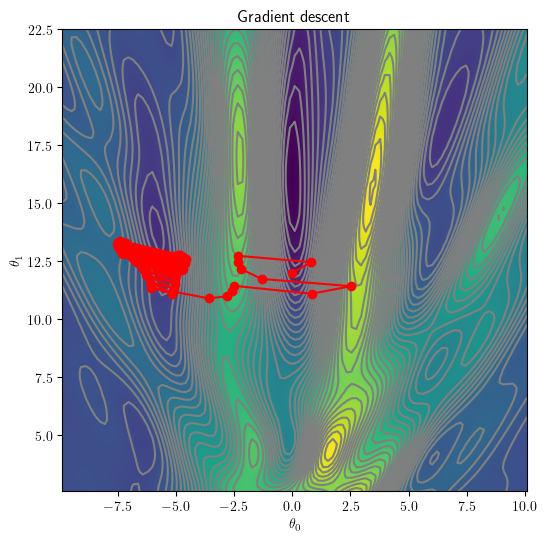

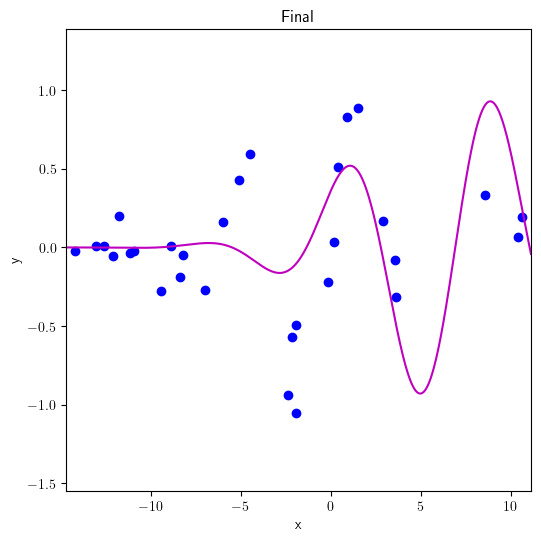

Final GD mse: 0.138296440243721


In [31]:
# gradient descent
thetas, losses = td.grad_descent(x,y, theta,lr=0.5,grad_func=hlp.gabor_gradient, model=hlp.gabor_model,n_epochs=100)

# plot losses
hlp.plot_loss(losses)

# plot loss contour
hlp.loss_contour(x,y,model=hlp.gabor_model,loss_func=td.mse,type=1,title="Gradient descent",theta_list=thetas) 

# plot final model
hlp.plot_model(x, y, thetas[:,-1:], model=hlp.gabor_model, title="Final")

# get mse
y_pred = hlp.gabor_model(x,thetas[:,-1:])
mse = td.mse(y, y_pred)
print(f'Final GD mse: {mse}')

<span style="color:red">**TODO 3:**</span> 
complete the stochastic gradient descent algorithm in the `todos.py` so that it operates over parameters $\theta$ as a vector and stores the history of the steps into a `torch.tensor`.

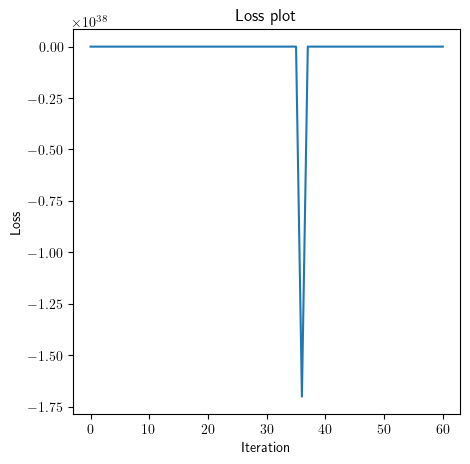

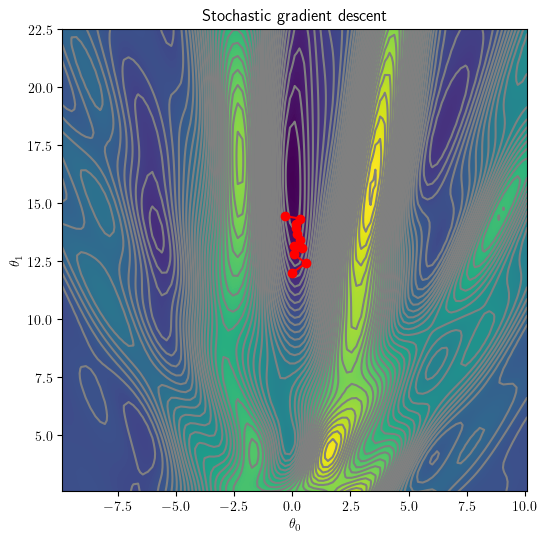

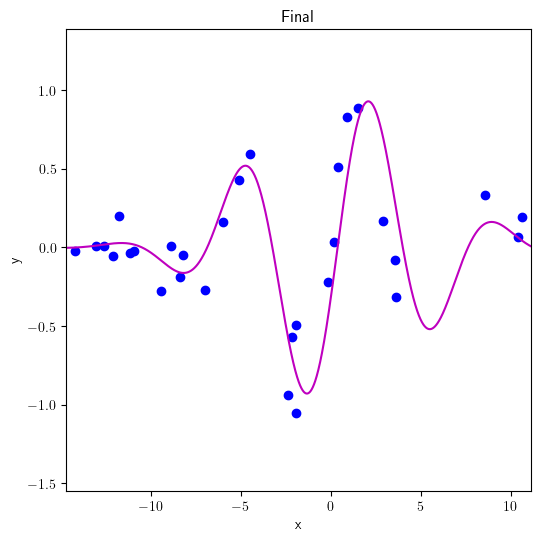

Final SGD mse: 0.0591437928378582


In [32]:
# stochastic gradient descent
thetas, losses = td.stochastic_grad_descent(x,y, theta,lr=0.5, bs=5,grad_func=hlp.gabor_gradient, model=hlp.gabor_model, n_epochs=10)

# plot losses
hlp.plot_loss(losses)

# plot loss contour
hlp.loss_contour(x,y,model=hlp.gabor_model,loss_func=td.mse,type=1,title="Stochastic gradient descent",theta_list=thetas) 

# plot final model
hlp.plot_model(x, y, thetas[:,-1:], model=hlp.gabor_model, title="Final")

# get mse
y_pred = hlp.gabor_model(x,thetas[:,-1:])
mse = td.mse(y, y_pred)
print(f'Final SGD mse: {mse}')

Next we add momentum to the SGD

<span style="color:red">**TODO 4:**</span> 
check the slides and complete the SGD with momentum in the `todos.py` so that it operates over parameters $\theta$ as a vector and stores the history of the steps into a `torch.tensor`.

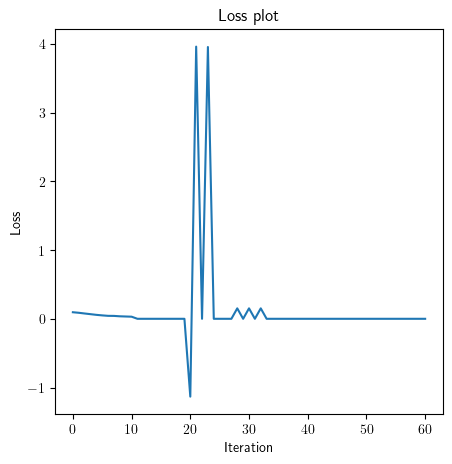

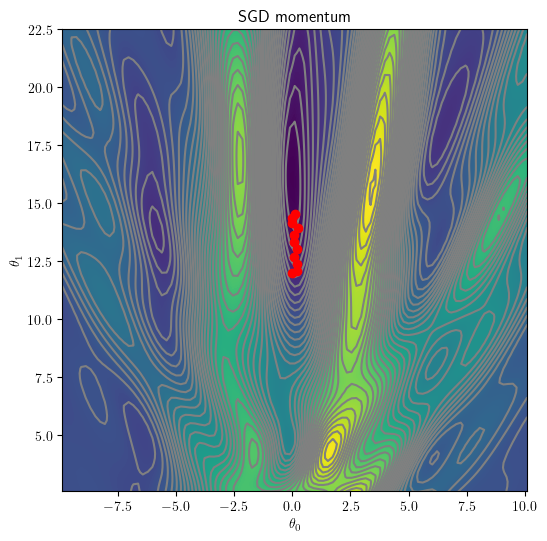

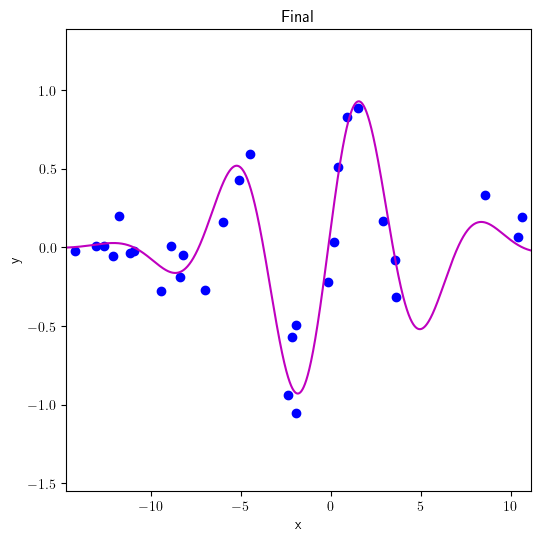

Final SGD with momentum mse: 0.03063584305346012


In [24]:
# stochastic gradient descent with momentum
thetas, losses = td.sgd_momentum(x,y, theta,lr=0.5,beta=0.9,bs=5,grad_func=hlp.gabor_gradient, model=hlp.gabor_model, n_epochs=10)

# plot losses
hlp.plot_loss(losses)

# plot loss contour
hlp.loss_contour(x,y,model=hlp.gabor_model,loss_func=td.mse,type=1,title="SGD momentum",theta_list=thetas) 

# plot final model
hlp.plot_model(x, y, thetas[:,-1:], model=hlp.gabor_model, title="Final")

# get mse
y_pred = hlp.gabor_model(x,thetas[:,-1:])
mse = td.mse(y, y_pred)
print(f'Final SGD with momentum mse: {mse}')

And accelerated Nestorov momentum

<span style="color:red">**TODO 5:**</span> 
check the slides and complete the SGD with accelerated nestorov momentum in the `todos.py` so that it operates over parameters $\theta$ as a vector and stores the history of the steps into a `torch.tensor`.

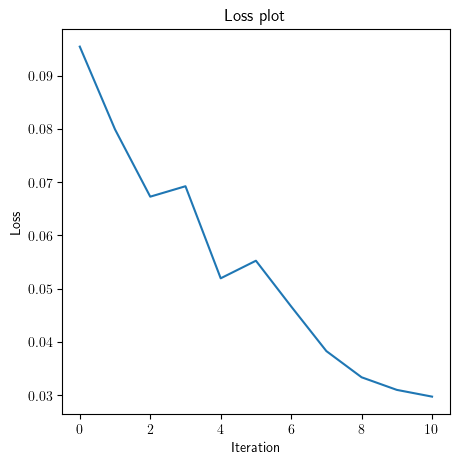

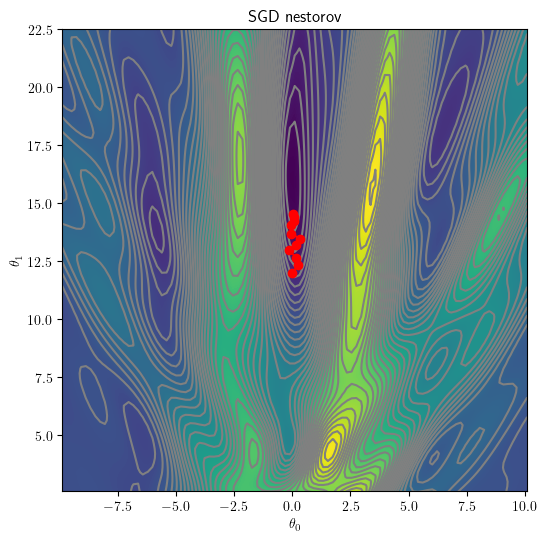

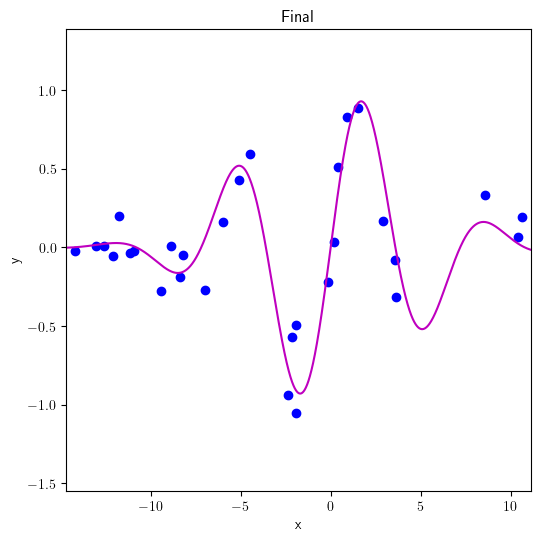

Final SGD with Nestorov momentum mse: 0.029710950329899788


In [25]:
# stochastic gradient descent with nestorov momentum
thetas, losses = td.sgd_nestorov(x,y, theta,lr=0.5,beta=0.6,bs=5,grad_func=hlp.gabor_gradient, model=hlp.gabor_model, n_epochs=10)

# plot losses
hlp.plot_loss(losses)

# plot loss contour
hlp.loss_contour(x,y,model=hlp.gabor_model,loss_func=td.mse,type=1,title="SGD nestorov",theta_list=thetas) 

# plot final model
hlp.plot_model(x, y, thetas[:,-1:], model=hlp.gabor_model, title="Final")

# get mse
y_pred = hlp.gabor_model(x,thetas[:,-1:])
mse = td.mse(y, y_pred)
print(f'Final SGD with Nestorov momentum mse: {mse}')

The final step is ADAM

<span style="color:red">**TODO 6:**</span> 
check the slides and complete ADAM in the `todos.py` so that it operates over parameters $\theta$ as a vector and stores the history of the steps into a `torch.tensor`.

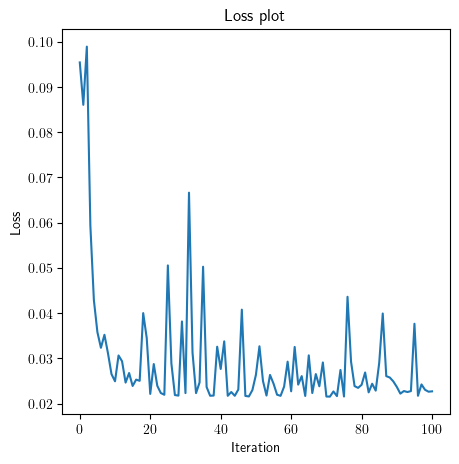

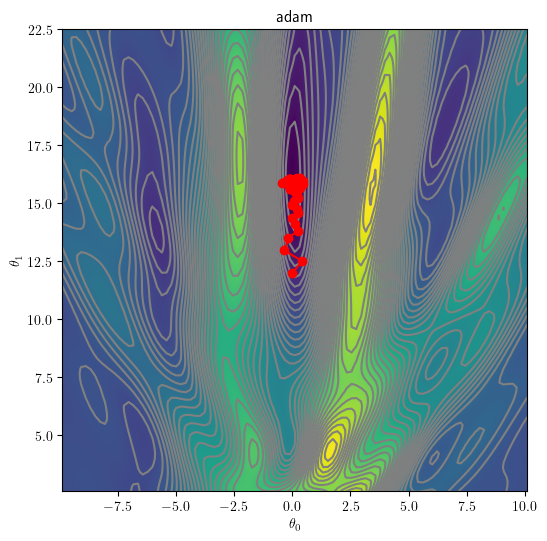

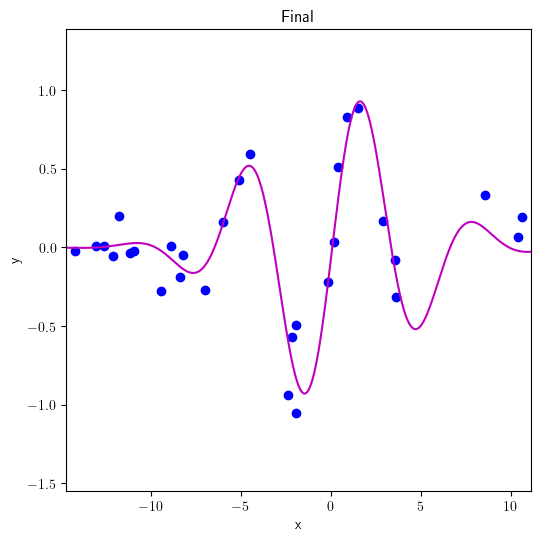

Final adam mse: 0.02270127274096012


In [29]:
# adam
thetas, losses = td.ADAM(x,y, theta,lr=10,beta=0.5, gamma=0.999,bs=5,grad_func=hlp.gabor_gradient, model=hlp.gabor_model, n_epochs=100)

# plot losses
hlp.plot_loss(losses)

# plot loss contour
hlp.loss_contour(x,y,model=hlp.gabor_model,loss_func=td.mse,type=1,title="adam",theta_list=thetas) 

# plot final model
hlp.plot_model(x, y, thetas[:,-1:], model=hlp.gabor_model, title="Final")

# get mse
y_pred = hlp.gabor_model(x,thetas[:,-1:])
mse = td.mse(y, y_pred)
print(f'Final adam mse: {mse}')